# Example 18 Analysis

We will plot the rate binned in energy deposition, as well as the cross section reach for explicit mediator masses.

## Packages

In [1]:
import numpy as np

# some personal preferences for nice plots
%run "../../utilities/output_parser/plotter.ipynb"

# helpful functions for processing output
import sys
sys.path.append("../../utilities/output_parser")
import EXDMDataHandler
from EXDMDataHandler import EXDMData

import seaborn as sns

## Data

In [2]:
data = EXDMData(filename = './output/EXDM_out_example_18.hdf5')

## Results

### Binned Scatter Rate

In [ ]:
mX_MeV = 10
mediator_masses = np.array([1e3,5e3,10e3,100e3]) # keV

[ E_bin_LHS, binned_scatter_rate_E_light ] = data.get_binned_scatter_rate_E(mass_MeV = mX_MeV, 
                                                                      med_FF = 2., 
                                                                      sigma_cm2 = 10**(-40),
                                                                      E_bin_width = 2,)

[ E_bin_LHS, binned_scatter_rate_E_heavy ] = data.get_binned_scatter_rate_E(mass_MeV = mX_MeV, 
                                                                      sigma_cm2 = 10**(-40),
                                                                      med_FF = 0,
                                                                      E_bin_width = 2)



[E_bin_LHS, binned_scatter_rate_E_mA0] = data.get_binned_scatter_rate_E(mass_MeV=mX_MeV,
                                                                      sigma_cm2 = 10**(-40),
                                                                      mass_A=mediator_masses[0],
                                                                      E_bin_width = 2)

[E_bin_LHS, binned_scatter_rate_E_mA1] = data.get_binned_scatter_rate_E(mass_MeV=mX_MeV,
                                                                      sigma_cm2 = 10**(-40),
                                                                      mass_A=mediator_masses[1],
                                                                      E_bin_width = 2)

[E_bin_LHS, binned_scatter_rate_E_mA2] = data.get_binned_scatter_rate_E(mass_MeV=mX_MeV,
                                                                      sigma_cm2 = 10**(-40),
                                                                      mass_A=mediator_masses[2],
                                                                      E_bin_width = 2)

[E_bin_LHS, binned_scatter_rate_E_mA3] = data.get_binned_scatter_rate_E(mass_MeV=mX_MeV,
                                                                      sigma_cm2 = 10**(-40),
                                                                      mass_A=mediator_masses[3],
                                                                      E_bin_width = 2)


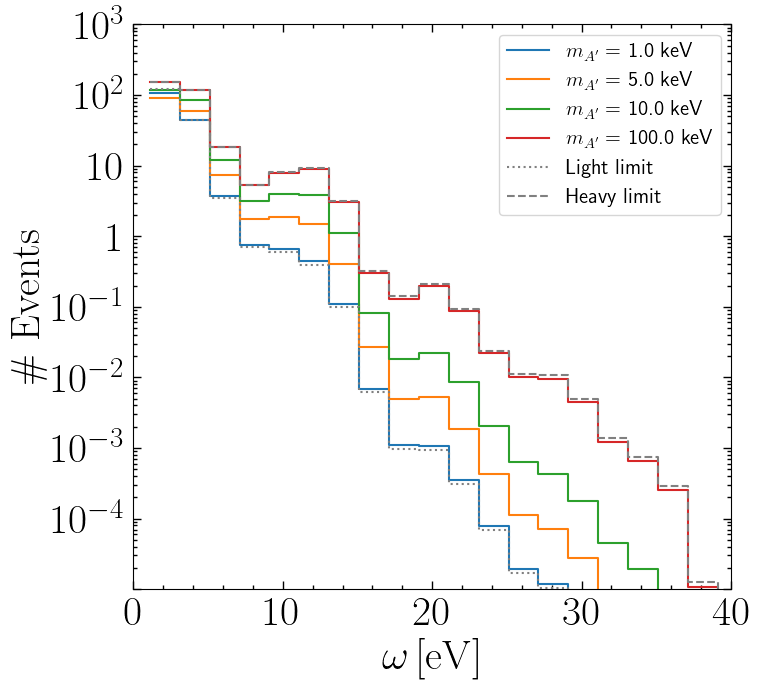

In [ ]:
save_fig = True

fig, axes = plt.subplots(nrows=1, ncols=1, 
                             figsize=(7*1.1, 7))

E_min = 0
E_max = 40
dE = 10.

log_events_min = -5
log_events_max = 3

set_custom_tick_options(axes)
set_custom_axes(axes, 'x', E_min, E_max,
               ax_type = 'lin', 
               label = r'$\omega \, [\mathrm{eV}]$', 
               step = dE)
set_custom_axes(axes, 'y', log_events_min, log_events_max,
               ax_type = 'log', 
               label = r'$\# \ \mathrm{Events}$', 
               show_first = False)


axes.step(
    E_bin_LHS, 
    np.log10(binned_scatter_rate_E_mA0),
    where = 'post',
    label=f'$m_{{A^\prime}}=$ {mediator_masses[0]/1000} keV'
)
axes.step(
    E_bin_LHS, 
    np.log10(binned_scatter_rate_E_mA1),
    where = 'post',
    label=f'$m_{{A^\prime}}=$ {mediator_masses[1]/1000} keV'
 )
axes.step(
    E_bin_LHS, 
    np.log10(binned_scatter_rate_E_mA2),
    where = 'post',
    label=f'$m_{{A^\prime}}=$ {mediator_masses[2]/1000} keV'
)
axes.step(
    E_bin_LHS, 
    np.log10(binned_scatter_rate_E_mA3),
    where = 'post',
    label=f'$m_{{A^\prime}}=$ {mediator_masses[3]/1000} keV'
)


axes.step(
    E_bin_LHS, 
    np.log10(binned_scatter_rate_E_light),
    where = 'post',
    linestyle='dotted',
    label='Light limit',
    color='gray'
)
axes.step(
    E_bin_LHS, 
    np.log10(binned_scatter_rate_E_heavy),
    where = 'post',
    linestyle='dashed',
    label='Heavy limit',
    color='gray'
)
axes.legend(fontsize=15);

fig.tight_layout()
    
if save_fig:
    plt.savefig('./output/Si_binned_scatter_rate_2x2x2.pdf', 
                bbox_inches='tight', pad_inches = 0.075)

plt.show()

### Cross Section Reach

#### Data

In [ ]:
# Plot sigma vs m_X for various different mediator masses between
# mA = 1 keV to 100 keV (the interesting regime)

mediator_masses = np.array([1e3,5e3,10e3,100e3]) # keV

[masses_MeV, cs_reach_0] = data.get_cs_reach(mass_A=mediator_masses[0])
[masses_MeV, cs_reach_1] = data.get_cs_reach(mass_A=mediator_masses[1])
[masses_MeV, cs_reach_2] = data.get_cs_reach(mass_A=mediator_masses[2])
[masses_MeV, cs_reach_3] = data.get_cs_reach(mass_A=mediator_masses[3])

[masses_MeV, cs_reach_heavy] = data.get_cs_reach(med_FF=0.)
[masses_MeV, cs_reach_light] = data.get_cs_reach(med_FF=2.)


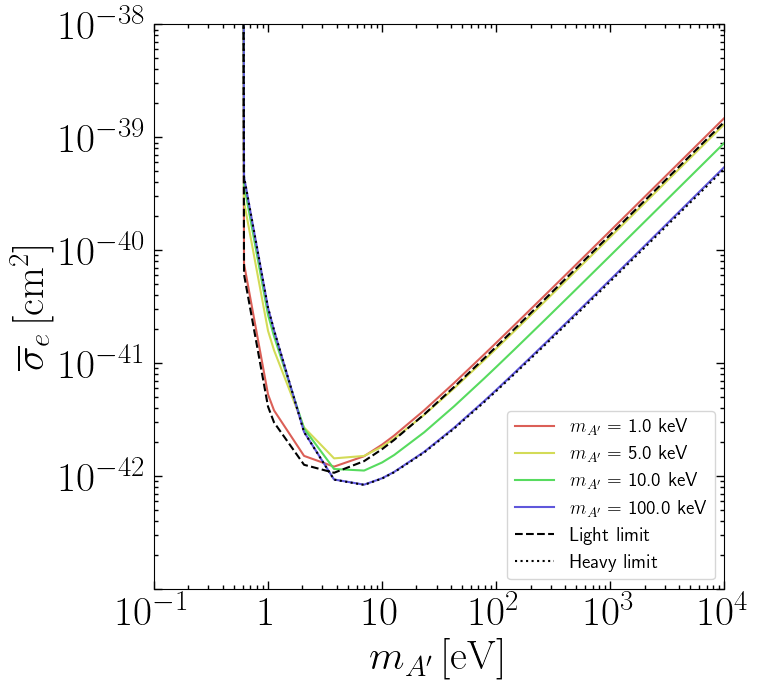

In [ ]:
colors = sns.color_palette("hls", 6)

fig, axes = plt.subplots(nrows=1, ncols=1, 
                             figsize=(7*1.1, 7))

log_mX_min = -1
log_mX_max = 4

log_cs_min = -43
log_cs_max = -38

set_custom_tick_options(axes)
set_custom_axes(axes, 'x', log_mX_min, log_mX_max,
               ax_type = 'log', 
               label = r'$m_{A^{\prime}} \, [\mathrm{eV}]$')
set_custom_axes(axes, 'y', log_cs_min, log_cs_max,
               ax_type = 'log', 
               label = r'$\overline{\sigma}_e \, [\mathrm{cm}^2]$', 
               show_first = False)


axes.plot(
    np.log10(masses_MeV), 
    np.log10(cs_reach_0),
    label=f'$m_{{A^\prime}}=$ {mediator_masses[0]/1000} keV',
    color = colors[0]
)

axes.plot(
    np.log10(masses_MeV), 
    np.log10(cs_reach_1),
    label=f'$m_{{A^\prime}}=$ {mediator_masses[1]/1000} keV',
    color = colors[1]
)
axes.plot(
    np.log10(masses_MeV), 
    np.log10(cs_reach_2),
    label=f'$m_{{A^\prime}}=$ {mediator_masses[2]/1000} keV',
    color = colors[2]
)
axes.plot(
    np.log10(masses_MeV), 
    np.log10(cs_reach_3),
    label=f'$m_{{A^\prime}}=$ {mediator_masses[3]/1000} keV',
    color = colors[3]
)


axes.plot(
    np.log10(masses_MeV), 
    np.log10(cs_reach_light),
    label=f'Light limit',
    linestyle='dashed',
    color = 'black'
)
axes.plot(
    np.log10(masses_MeV), 
    np.log10(cs_reach_heavy),
    label=f'Heavy limit',
    linestyle='dotted',
    color = 'black'
)

axes.legend(fontsize=14)

fig.tight_layout()
